# Superstore Sales Analysis
## Notebook 02: Sales Performance Analysis

### Objective
This notebook analyzes the overall sales performance of the Superstore dataset.

The main goals are to:
- Calculate key business metrics such as total sales, profit, orders, and profit margin
- Analyze sales and profit trends over time
- Identify the best and worst performing years, months, and quarters
- Detect seasonality patterns in sales performance
- Generate business insights and recommendations

In [1]:
# IMPORT LIBRARIES

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import matplotlib.dates as mdates

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.2f}'.format)

# Visualization style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Create folders if they do not exist
os.makedirs('images', exist_ok=True)
os.makedirs('reports/tables', exist_ok=True)

print("Libraries imported successfully")

Libraries imported successfully


In [2]:
# LOAD CLEANED DATA

df = pd.read_csv(r'C:\Users\admin\Desktop\ProjectDAcommerc\data\superstore_cleaned.csv')

print("Cleaned data loaded successfully")
print(f"Shape: {df.shape}")
df.head()

Cleaned data loaded successfully
Shape: (9994, 27)


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Order Year,Order Month,Order Month Name,Order Quarter,Profit Margin (%),Shipping Days
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.96,2,0.00,41.91,2016,11,Nov,4,16.00,3
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.94,3,0.00,219.58,2016,11,Nov,4,30.00,3
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.62,2,0.00,6.87,2016,6,Jun,2,47.00,4
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.58,5,0.45,-383.03,2015,10,Oct,4,-40.00,7
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.37,2,0.20,2.52,2015,10,Oct,4,11.25,7


In [5]:
# CHECK DATA TYPES

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 27 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Row ID             9994 non-null   int64         
 1   Order ID           9994 non-null   object        
 2   Order Date         9994 non-null   datetime64[ns]
 3   Ship Date          9994 non-null   datetime64[ns]
 4   Ship Mode          9994 non-null   object        
 5   Customer ID        9994 non-null   object        
 6   Customer Name      9994 non-null   object        
 7   Segment            9994 non-null   object        
 8   Country            9994 non-null   object        
 9   City               9994 non-null   object        
 10  State              9994 non-null   object        
 11  Postal Code        9994 non-null   int64         
 12  Region             9994 non-null   object        
 13  Product ID         9994 non-null   object        
 14  Category

In [4]:
# CONVERT DATE COLUMNS

df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

print("Date columns converted successfully")
print(df[['Order Date', 'Ship Date']].dtypes)

Date columns converted successfully
Order Date    datetime64[ns]
Ship Date     datetime64[ns]
dtype: object


In [6]:
# VERIFY REQUIRED COLUMNS

required_columns = [
    'Order ID',
    'Order Date',
    'Sales',
    'Profit',
    'Quantity',
    'Discount',
    'Order Year',
    'Order Month',
    'Order Quarter'
]

missing_cols = [col for col in required_columns if col not in df.columns]

if len(missing_cols) == 0:
    print("All required columns are available")
else:
    print("Missing columns:")
    print(missing_cols)

All required columns are available


In [7]:
# HELPER FUNCTIONS 

def format_currency(value):
    return f"${value:,.2f}"

def format_number(value):
    return f"{value:,.0f}"

def format_percent(value):
    return f"{value:.2f}%"

print("Helper functions created")

Helper functions created


## 1. Overall Business Performance

In this section, we calculate the key business metrics:
- Total Sales
- Total Profit
- Total Orders
- Total Quantity Sold
- Total Customers
- Profit Margin
- Average Order Value

In [8]:
# OVERALL KPI CALCULATION 

total_sales = df['Sales'].sum()
total_profit = df['Profit'].sum()
total_orders = df['Order ID'].nunique()
total_quantity = df['Quantity'].sum()
total_customers = df['Customer ID'].nunique()
profit_margin = total_profit / total_sales * 100
avg_order_value = total_sales / total_orders

kpi_summary = pd.DataFrame({
    'Metric': [
        'Total Sales',
        'Total Profit',
        'Total Orders',
        'Total Quantity Sold',
        'Total Customers',
        'Profit Margin',
        'Average Order Value'
    ],
    'Value': [
        format_currency(total_sales),
        format_currency(total_profit),
        format_number(total_orders),
        format_number(total_quantity),
        format_number(total_customers),
        format_percent(profit_margin),
        format_currency(avg_order_value)
    ]
})

kpi_summary

,Metric,Value
0,Total Sales,"$2,297,200.86"
1,Total Profit,"$286,397.02"
2,Total Orders,"5,009"
3,Total Quantity Sold,"37,873"
4,Total Customers,793
5,Profit Margin,12.47%
6,Average Order Value,$458.61


In [9]:
print("=" * 50)
print("OVERALL BUSINESS PERFORMANCE")
print("=" * 50)

print(f"Total Sales:          {format_currency(total_sales)}")
print(f"Total Profit:         {format_currency(total_profit)}")
print(f"Total Orders:         {format_number(total_orders)}")
print(f"Total Quantity Sold:  {format_number(total_quantity)}")
print(f"Total Customers:      {format_number(total_customers)}")
print(f"Profit Margin:        {format_percent(profit_margin)}")
print(f"Average Order Value:  {format_currency(avg_order_value)}")

OVERALL BUSINESS PERFORMANCE
Total Sales:          $2,297,200.86
Total Profit:         $286,397.02
Total Orders:         5,009
Total Quantity Sold:  37,873
Total Customers:      793
Profit Margin:        12.47%
Average Order Value:  $458.61


In [11]:
# SAVE KPI SUMMARY 

kpi_summary.to_csv(r'C:\Users\admin\Desktop\ProjectDAcommerc\reports\kpi_summary.csv', index=False)

print("KPI summary saved successfully")

KPI summary saved successfully


### Initial Observation

The dataset provides a high-level view of Superstore's sales performance.  
The most important metrics are total sales, total profit, and profit margin because they show not only revenue generation but also business profitability.

Further analysis is needed to understand how these metrics change over time.

## 2. Sales and Profit Performance by Year

Business question:

**How do sales and profit change across years?**

In [12]:
# YEARLY SALES PERFORMANCE

yearly_performance = df.groupby('Order Year').agg(
    Total_Sales=('Sales', 'sum'),
    Total_Profit=('Profit', 'sum'),
    Total_Orders=('Order ID', 'nunique'),
    Total_Quantity=('Quantity', 'sum')
).reset_index()

# Profit Margin
yearly_performance['Profit_Margin_%'] = (
    yearly_performance['Total_Profit'] / yearly_performance['Total_Sales'] * 100
).round(2)

# YoY Growth
yearly_performance['Sales_YoY_Growth_%'] = (
    yearly_performance['Total_Sales'].pct_change() * 100
).round(2)

yearly_performance['Profit_YoY_Growth_%'] = (
    yearly_performance['Total_Profit'].pct_change() * 100
).round(2)

yearly_performance

,Order Year,Total_Sales,Total_Profit,Total_Orders,Total_Quantity,Profit_Margin_%,Sales_YoY_Growth_%,Profit_YoY_Growth_%
0,2014,484247.50,49543.97,969,7581,10.23,NaN,NaN
1,2015,470532.51,61618.60,1038,7979,13.10,-2.83,24.37
2,2016,609205.60,81795.17,1315,9837,13.43,29.47,32.74
3,2017,733215.26,93439.27,1687,12476,12.74,20.36,14.24


In [13]:
yearly_performance.to_csv('reports/tables/yearly_performance.csv', index=False)

print("Yearly performance table saved successfully")

Yearly performance table saved successfully


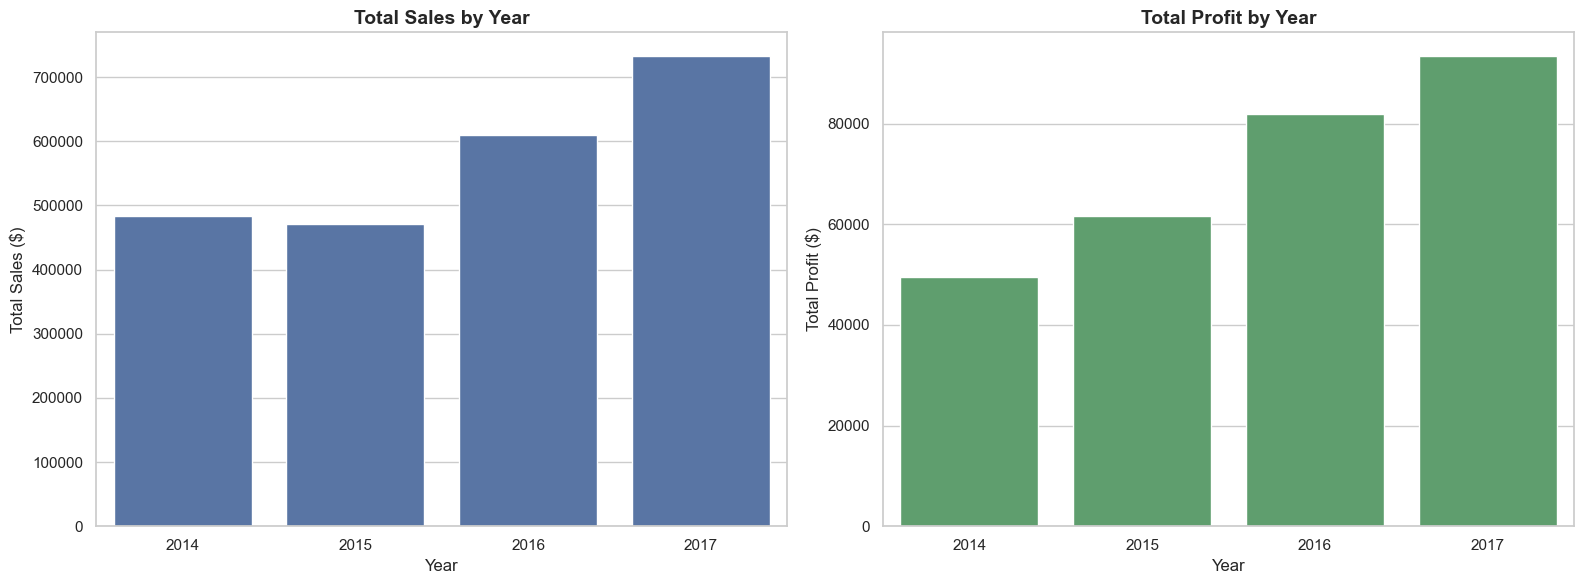

In [14]:
# VISUALIZE SALES AND PROFIT BY YEAR

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Sales by Year
sns.barplot(
    data=yearly_performance,
    x='Order Year',
    y='Total_Sales',
    ax=axes[0],
    color='#4C72B0'
)

axes[0].set_title('Total Sales by Year', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Total Sales ($)')

# Profit by Year
sns.barplot(
    data=yearly_performance,
    x='Order Year',
    y='Total_Profit',
    ax=axes[1],
    color='#55A868'
)

axes[1].set_title('Total Profit by Year', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Total Profit ($)')

plt.tight_layout()
plt.savefig('images/sales_profit_by_year.png', dpi=150, bbox_inches='tight')
plt.show()

In [15]:
# YEARLY PERFORMANCE INSIGHTS

best_sales_year = yearly_performance.loc[
    yearly_performance['Total_Sales'].idxmax()
]

best_profit_year = yearly_performance.loc[
    yearly_performance['Total_Profit'].idxmax()
]

worst_profit_year = yearly_performance.loc[
    yearly_performance['Total_Profit'].idxmin()
]

print("YEARLY PERFORMANCE INSIGHTS")
print("=" * 50)

print(f"Best sales year: {int(best_sales_year['Order Year'])} "
      f"with {format_currency(best_sales_year['Total_Sales'])}")

print(f"Best profit year: {int(best_profit_year['Order Year'])} "
      f"with {format_currency(best_profit_year['Total_Profit'])}")

print(f"Lowest profit year: {int(worst_profit_year['Order Year'])} "
      f"with {format_currency(worst_profit_year['Total_Profit'])}")

YEARLY PERFORMANCE INSIGHTS
Best sales year: 2017 with $733,215.26
Best profit year: 2017 with $93,439.27
Lowest profit year: 2014 with $49,543.97


### Insight
- Sales increased over the analyzed period, indicating overall business growth.
- The year with the highest sales was 2017 identified from the yearly performance table.
- Profit did not always grow at the same rate as sales, which suggests that revenue growth should be evaluated together with profitability.

### Recommendation
- Continue investing in growth strategies during high-performing years.
- Monitor profit margin closely, not only total sales.
- Investigate years where sales increased but profit growth was weak.

## 3. Monthly Sales Trend

Business question:

**How do sales and profit change month by month over time?**

In [16]:
# MONTHLY SALES TREND

monthly_trend = df.groupby(['Order Year', 'Order Month']).agg(
    Total_Sales=('Sales', 'sum'),
    Total_Profit=('Profit', 'sum'),
    Total_Orders=('Order ID', 'nunique')
).reset_index()

# Create a proper date column for plotting
monthly_trend['Month_Start'] = pd.to_datetime(
    monthly_trend['Order Year'].astype(str) + '-' +
    monthly_trend['Order Month'].astype(str) + '-01'
)

monthly_trend = monthly_trend.sort_values('Month_Start')

monthly_trend.head()

,Order Year,Order Month,Total_Sales,Total_Profit,Total_Orders,Month_Start
0,2014,1,14236.90,2450.19,32,2014-01-01
1,2014,2,4519.89,862.31,28,2014-02-01
2,2014,3,55691.01,498.73,71,2014-03-01
3,2014,4,28295.35,3488.84,66,2014-04-01
4,2014,5,23648.29,2738.71,69,2014-05-01


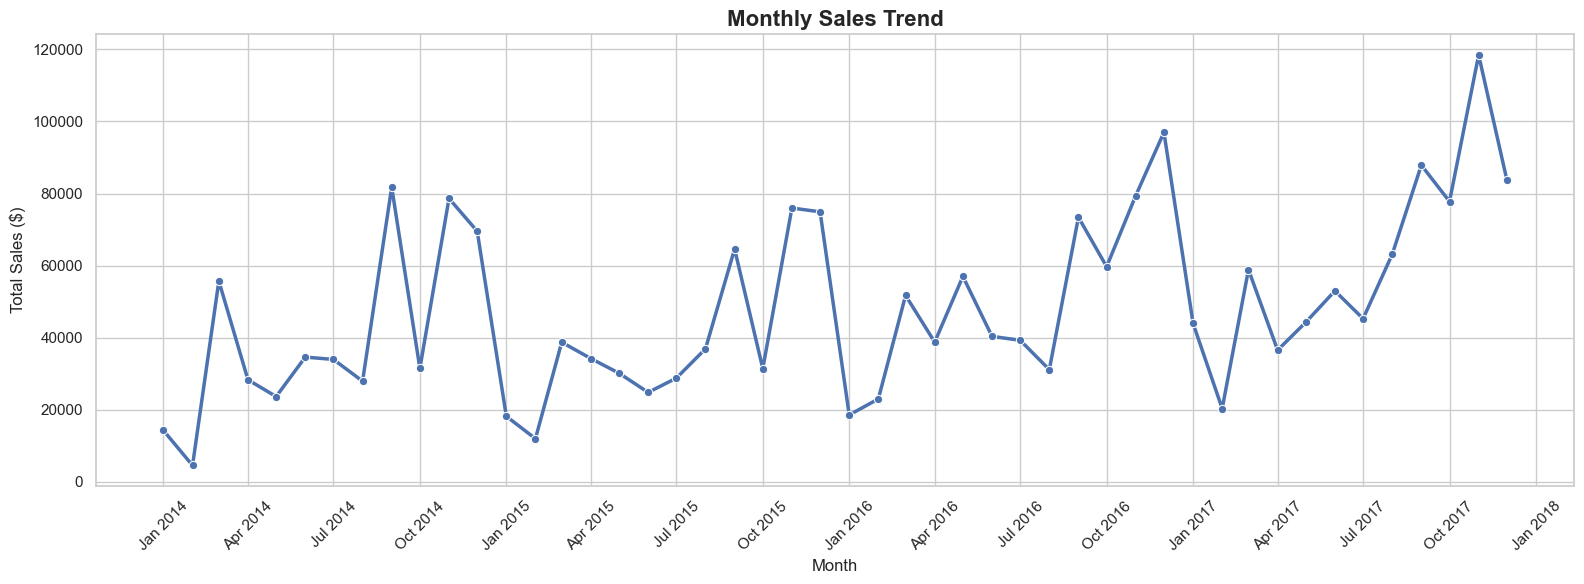

In [17]:
# VISUALIZE MONTHLY SALES TREND 

plt.figure(figsize=(16, 6))

sns.lineplot(
    data=monthly_trend,
    x='Month_Start',
    y='Total_Sales',
    marker='o',
    linewidth=2.5,
    color='#4C72B0'
)

plt.title('Monthly Sales Trend', fontsize=16, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Total Sales ($)')

plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('images/monthly_sales_trend.png', dpi=150, bbox_inches='tight')
plt.show()

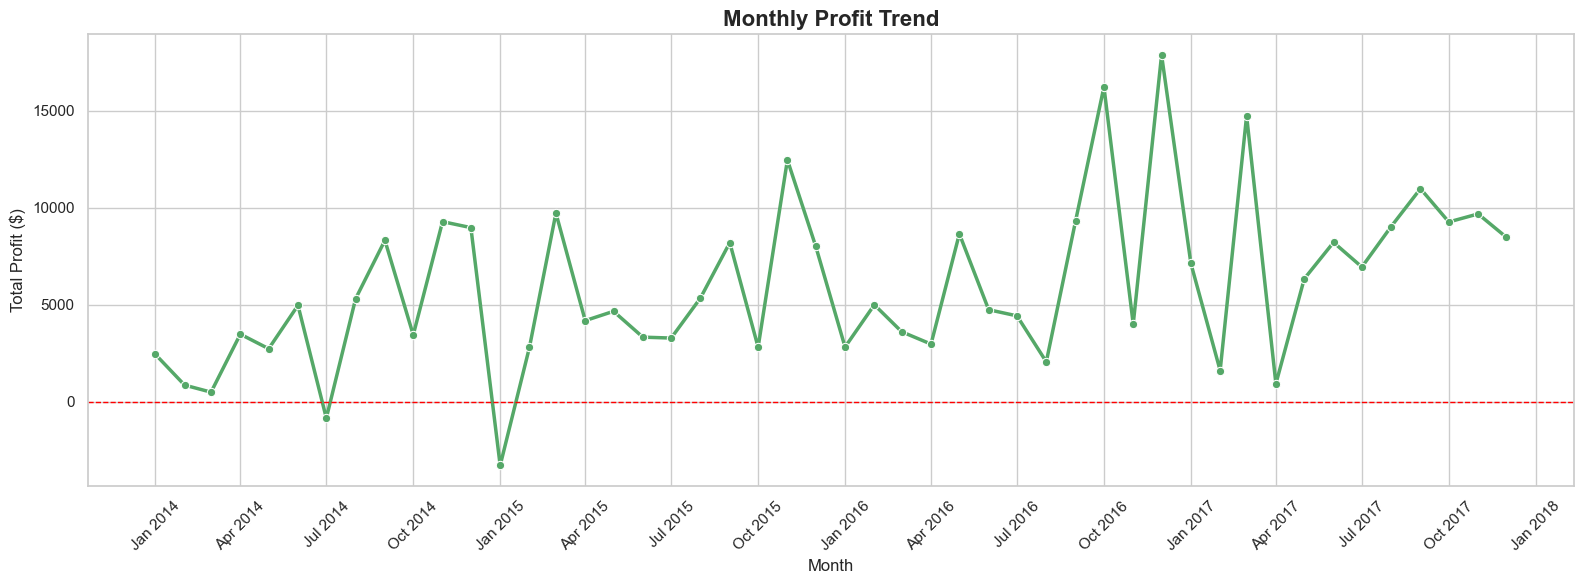

In [18]:
# VISUALIZE MONTHLY PROFIT TREND

plt.figure(figsize=(16, 6))

sns.lineplot(
    data=monthly_trend,
    x='Month_Start',
    y='Total_Profit',
    marker='o',
    linewidth=2.5,
    color='#55A868'
)

plt.axhline(0, color='red', linestyle='--', linewidth=1)

plt.title('Monthly Profit Trend', fontsize=16, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Total Profit ($)')

plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('images/monthly_profit_trend.png', dpi=150, bbox_inches='tight')
plt.show()

In [19]:
# BEST AND WORST MONTHS

best_sales_month = monthly_trend.loc[
    monthly_trend['Total_Sales'].idxmax()
]

worst_sales_month = monthly_trend.loc[
    monthly_trend['Total_Sales'].idxmin()
]

best_profit_month = monthly_trend.loc[
    monthly_trend['Total_Profit'].idxmax()
]

worst_profit_month = monthly_trend.loc[
    monthly_trend['Total_Profit'].idxmin()
]

print("MONTHLY PERFORMANCE INSIGHTS")
print("=" * 50)

print(f"Best sales month: {best_sales_month['Month_Start'].strftime('%b %Y')} "
      f"with {format_currency(best_sales_month['Total_Sales'])}")

print(f"Worst sales month: {worst_sales_month['Month_Start'].strftime('%b %Y')} "
      f"with {format_currency(worst_sales_month['Total_Sales'])}")

print(f"Best profit month: {best_profit_month['Month_Start'].strftime('%b %Y')} "
      f"with {format_currency(best_profit_month['Total_Profit'])}")

print(f"Worst profit month: {worst_profit_month['Month_Start'].strftime('%b %Y')} "
      f"with {format_currency(worst_profit_month['Total_Profit'])}")

MONTHLY PERFORMANCE INSIGHTS
Best sales month: Nov 2017 with $118,447.82
Worst sales month: Feb 2014 with $4,519.89
Best profit month: Dec 2016 with $17,885.31
Worst profit month: Jan 2015 with $-3,281.01


In [20]:
monthly_trend.to_csv('reports/tables/monthly_trend.csv', index=False)

print("Monthly trend table saved successfully")

Monthly trend table saved successfully


### Insight

- Monthly sales fluctuate over time, suggesting that sales performance is not evenly distributed throughout the year.
- Some months generate significantly higher sales than others.
- Profit trend should be compared with sales trend to detect months where high revenue does not result in strong profitability.

### Recommendation

- Identify peak sales months and prepare inventory, marketing campaigns, and staffing in advance.
- Investigate low-profit months to understand whether discounts, product mix, or regional performance affected profitability.

## 4. Seasonality Analysis

Business question:

**Is there any seasonal pattern in sales performance?**

To answer this question, we aggregate sales and profit by month across all years.

In [21]:
# SEASONALITY BY MONTH 

seasonality = df.groupby('Order Month').agg(
    Total_Sales=('Sales', 'sum'),
    Total_Profit=('Profit', 'sum'),
    Total_Orders=('Order ID', 'nunique')
).reset_index()

month_map = {
    1: 'Jan', 2: 'Feb', 3: 'Mar', 4: 'Apr',
    5: 'May', 6: 'Jun', 7: 'Jul', 8: 'Aug',
    9: 'Sep', 10: 'Oct', 11: 'Nov', 12: 'Dec'
}

seasonality['Month_Name'] = seasonality['Order Month'].map(month_map)

seasonality

,Order Month,Total_Sales,Total_Profit,Total_Orders,Month_Name
0,1,94924.84,9134.45,178,Jan
1,2,59751.25,10294.61,162,Feb
2,3,205005.49,28594.69,354,Mar
3,4,137762.13,11587.44,343,Apr
4,5,155028.81,22411.31,369,May
5,6,152718.68,21285.80,364,Jun
6,7,147238.10,13832.66,338,Jul
7,8,159044.06,21776.94,341,Aug
8,9,307649.95,36857.48,688,Sep
9,10,200322.98,31784.04,417,Oct


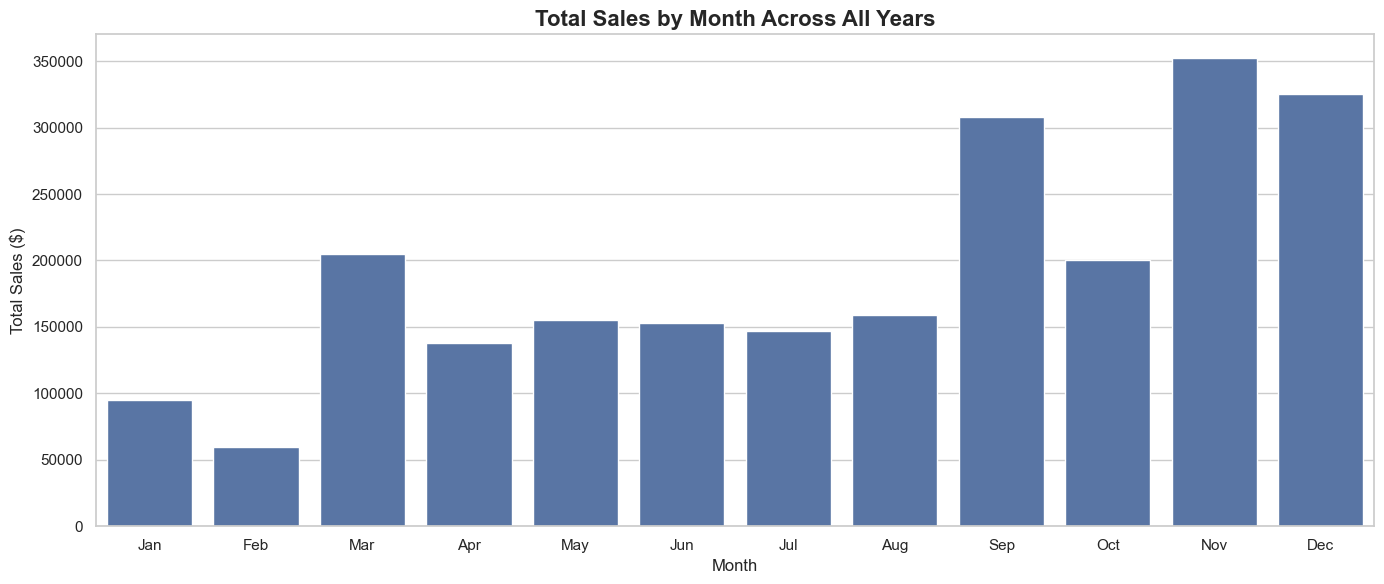

In [22]:
# VISUALIZE SALES SEASONALITY 

plt.figure(figsize=(14, 6))

sns.barplot(
    data=seasonality,
    x='Month_Name',
    y='Total_Sales',
    color='#4C72B0'
)

plt.title('Total Sales by Month Across All Years', fontsize=16, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Total Sales ($)')

plt.tight_layout()
plt.savefig('images/sales_seasonality_by_month.png', dpi=150, bbox_inches='tight')
plt.show()

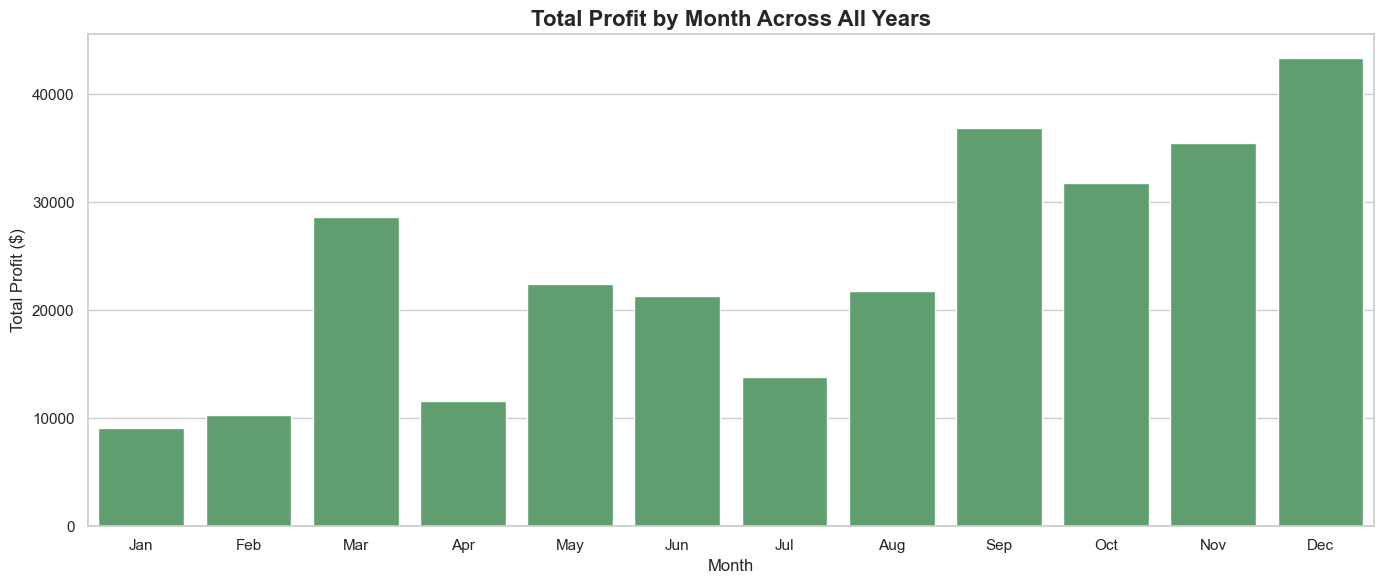

In [23]:
# VISUALIZE PROFIT SEASONALITY 

plt.figure(figsize=(14, 6))

sns.barplot(
    data=seasonality,
    x='Month_Name',
    y='Total_Profit',
    color='#55A868'
)

plt.axhline(0, color='red', linestyle='--', linewidth=1)

plt.title('Total Profit by Month Across All Years', fontsize=16, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Total Profit ($)')

plt.tight_layout()
plt.savefig('images/profit_seasonality_by_month.png', dpi=150, bbox_inches='tight')
plt.show()

In [24]:
# SEASONALITY INSIGHTS 

best_sales_month_season = seasonality.loc[
    seasonality['Total_Sales'].idxmax()
]

worst_sales_month_season = seasonality.loc[
    seasonality['Total_Sales'].idxmin()
]

best_profit_month_season = seasonality.loc[
    seasonality['Total_Profit'].idxmax()
]

worst_profit_month_season = seasonality.loc[
    seasonality['Total_Profit'].idxmin()
]

print("SEASONALITY INSIGHTS")
print("=" * 50)

print(f"Highest sales month overall: {best_sales_month_season['Month_Name']} "
      f"with {format_currency(best_sales_month_season['Total_Sales'])}")

print(f"Lowest sales month overall: {worst_sales_month_season['Month_Name']} "
      f"with {format_currency(worst_sales_month_season['Total_Sales'])}")

print(f"Highest profit month overall: {best_profit_month_season['Month_Name']} "
      f"with {format_currency(best_profit_month_season['Total_Profit'])}")

print(f"Lowest profit month overall: {worst_profit_month_season['Month_Name']} "
      f"with {format_currency(worst_profit_month_season['Total_Profit'])}")

SEASONALITY INSIGHTS
Highest sales month overall: Nov with $352,461.07
Lowest sales month overall: Feb with $59,751.25
Highest profit month overall: Dec with $43,369.19
Lowest profit month overall: Jan with $9,134.45


In [25]:
seasonality.to_csv('reports/tables/seasonality_by_month.csv', index=False)

print("Seasonality table saved successfully")

Seasonality table saved successfully


### Insight



### Recommendation



## 5. Quarterly Performance

Business question:

**Which quarter performs best in terms of sales and profit?**

In [26]:
# QUARTERLY PERFORMANCE 

quarterly_performance = df.groupby(['Order Year', 'Order Quarter']).agg(
    Total_Sales=('Sales', 'sum'),
    Total_Profit=('Profit', 'sum'),
    Total_Orders=('Order ID', 'nunique')
).reset_index()

quarterly_performance['Year_Quarter'] = (
    quarterly_performance['Order Year'].astype(str) 
    + '-Q' 
    + quarterly_performance['Order Quarter'].astype(str)
)

quarterly_performance['Profit_Margin_%'] = (
    quarterly_performance['Total_Profit'] / quarterly_performance['Total_Sales'] * 100
).round(2)

quarterly_performance

,Order Year,Order Quarter,Total_Sales,Total_Profit,Total_Orders,Year_Quarter,Profit_Margin_%
0,2014,1,74447.80,3811.23,131,2014-Q1,5.12
1,2014,2,86538.76,11204.07,201,2014-Q2,12.95
2,2014,3,143633.21,12804.72,267,2014-Q3,8.91
3,2014,4,179627.73,21723.95,370,2014-Q4,12.09
4,2015,1,68851.74,9264.94,144,2015-Q1,13.46
5,2015,2,89124.19,12190.92,214,2015-Q2,13.68
6,2015,3,130259.58,16853.62,274,2015-Q3,12.94
7,2015,4,182297.01,23309.12,406,2015-Q4,12.79
8,2016,1,93237.18,11441.37,179,2016-Q1,12.27
9,2016,2,136082.30,16390.34,294,2016-Q2,12.04


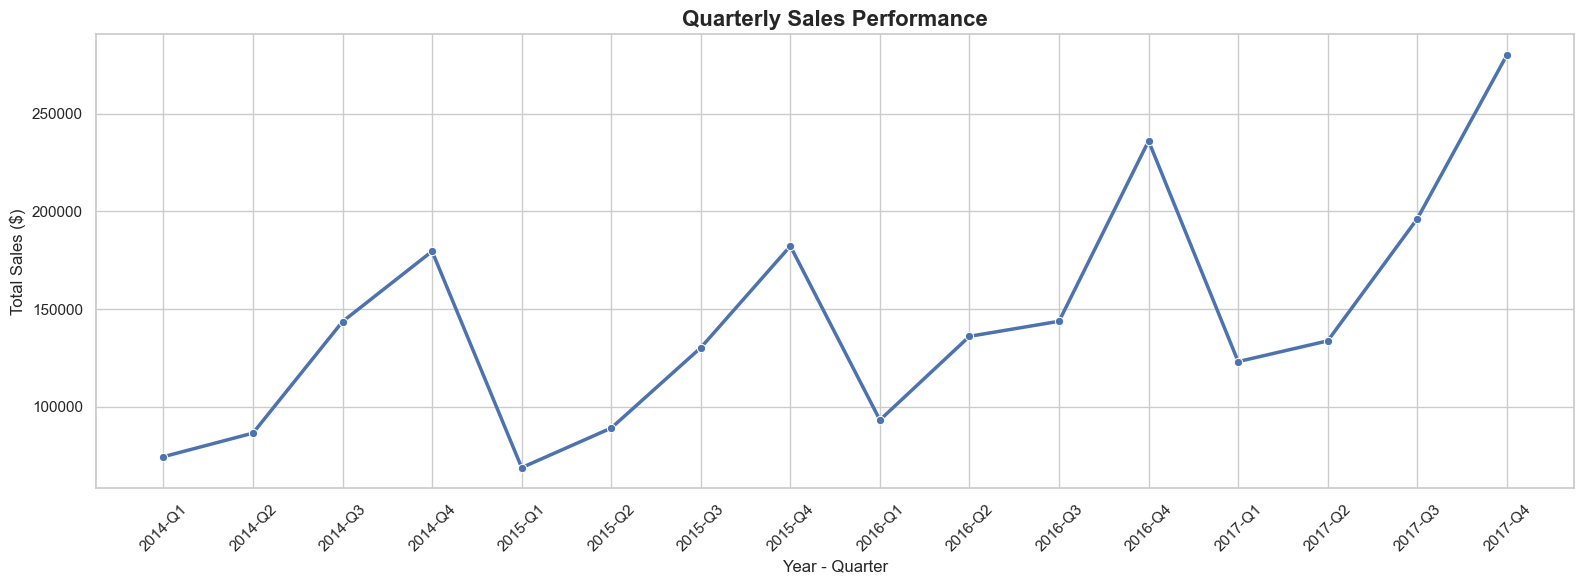

In [27]:
# VISUALIZE QUARTERLY SALES 

plt.figure(figsize=(16, 6))

sns.lineplot(
    data=quarterly_performance,
    x='Year_Quarter',
    y='Total_Sales',
    marker='o',
    linewidth=2.5,
    color='#4C72B0'
)

plt.title('Quarterly Sales Performance', fontsize=16, fontweight='bold')
plt.xlabel('Year - Quarter')
plt.ylabel('Total Sales ($)')

plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('images/quarterly_sales_performance.png', dpi=150, bbox_inches='tight')
plt.show()

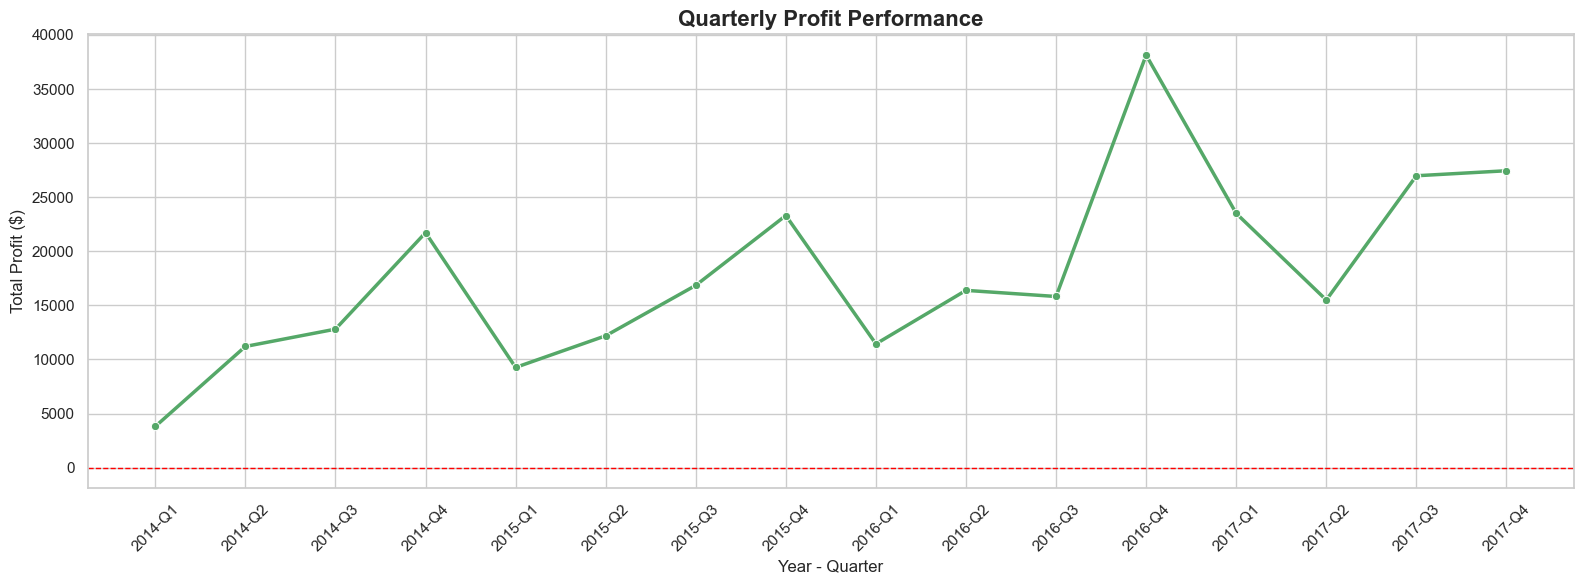

In [28]:
# VISUALIZE QUARTERLY PROFIT 

plt.figure(figsize=(16, 6))

sns.lineplot(
    data=quarterly_performance,
    x='Year_Quarter',
    y='Total_Profit',
    marker='o',
    linewidth=2.5,
    color='#55A868'
)

plt.axhline(0, color='red', linestyle='--', linewidth=1)

plt.title('Quarterly Profit Performance', fontsize=16, fontweight='bold')
plt.xlabel('Year - Quarter')
plt.ylabel('Total Profit ($)')

plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('images/quarterly_profit_performance.png', dpi=150, bbox_inches='tight')
plt.show()

In [29]:
# QUARTERLY INSIGHTS 

best_sales_quarter = quarterly_performance.loc[
    quarterly_performance['Total_Sales'].idxmax()
]

best_profit_quarter = quarterly_performance.loc[
    quarterly_performance['Total_Profit'].idxmax()
]

worst_profit_quarter = quarterly_performance.loc[
    quarterly_performance['Total_Profit'].idxmin()
]

print("QUARTERLY PERFORMANCE INSIGHTS")
print("=" * 50)

print(f"Best sales quarter: {best_sales_quarter['Year_Quarter']} "
      f"with {format_currency(best_sales_quarter['Total_Sales'])}")

print(f"Best profit quarter: {best_profit_quarter['Year_Quarter']} "
      f"with {format_currency(best_profit_quarter['Total_Profit'])}")

print(f"Lowest profit quarter: {worst_profit_quarter['Year_Quarter']} "
      f"with {format_currency(worst_profit_quarter['Total_Profit'])}")

QUARTERLY PERFORMANCE INSIGHTS
Best sales quarter: 2017-Q4 with $280,054.07
Best profit quarter: 2016-Q4 with $38,139.86
Lowest profit quarter: 2014-Q1 with $3,811.23


In [30]:
quarterly_performance.to_csv('reports/tables/quarterly_performance.csv', index=False)

print("Quarterly performance table saved successfully")

Quarterly performance table saved successfully


### Insight



### Recommendation



## 6. Final Summary

In [33]:
# FINAL SUMMARY

print("=" * 60)
print("SALES PERFORMANCE SUMMARY")
print("=" * 60)

print(f"Total Sales: {format_currency(total_sales)}")
print(f"Total Profit: {format_currency(total_profit)}")
print(f"Profit Margin: {format_percent(profit_margin)}")
print(f"Total Orders: {format_number(total_orders)}")
print(f"Average Order Value: {format_currency(avg_order_value)}")

print("\nBest Performing Periods:")
print(f"- Best Sales Year: {int(best_sales_year['Order Year'])}")
print(f"- Best Profit Year: {int(best_profit_year['Order Year'])}")
print(f"- Best Sales Month: {best_sales_month['Month_Start'].strftime('%b %Y')}")
print(f"- Best Profit Month: {best_profit_month['Month_Start'].strftime('%b %Y')}")
print(f"- Best Sales Quarter: {best_sales_quarter['Year_Quarter']}")
print(f"- Best Profit Quarter: {best_profit_quarter['Year_Quarter']}")


SALES PERFORMANCE SUMMARY
Total Sales: $2,297,200.86
Total Profit: $286,397.02
Profit Margin: 12.47%
Total Orders: 5,009
Average Order Value: $458.61

Best Performing Periods:
- Best Sales Year: 2017
- Best Profit Year: 2017
- Best Sales Month: Nov 2017
- Best Profit Month: Dec 2016
- Best Sales Quarter: 2017-Q4
- Best Profit Quarter: 2016-Q4


## Summary

In this notebook, we analyzed Superstore's sales performance from multiple time-based perspectives.

### Key Areas Covered
- Overall business KPIs
- Yearly sales and profit trends
- Monthly sales and profit trends
- Seasonality by month
- Quarterly sales and profit performance

### Main Takeaways
- Sales and profit should be analyzed together because high sales do not always mean high profitability.
- Monthly and quarterly trends help identify seasonal demand patterns.
- These insights can support better planning for marketing, inventory, and pricing strategies.

### Next 
Notebook 03 will focus on **Product Analysis**, including:
- Category performance
- Sub-category profitability
- Top and bottom products
- Products or categories causing losses